In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import json
import numpy as np
import pandas as pd
import time
import scipy

In [2]:
def plot_naive(file):
	# retrieve data
	with open(file, 'r') as f:
		data = json.load(f)
		
		x = [item['x'] for item in data]
		y = [item['y'] for item in data]

	# plot
	plt.figure(figsize=(25, 6))
	plt.plot(x, y)
	plt.title(f"Signal: $G(x) = \\cos(2\\pi \\cdot 3x)$")
	plt.xlabel("Time (s)")
	plt.grid(True)
	plt.show()

In [3]:
def plot_2D(file):
	# retrieve data
	with open(file, 'r') as f:
		data = json.load(f)
		
		x = [item['x'] for item in data]
		y = [item['y'] for item in data]
		Gxy = [item['z'] for item in data]

		# plot
		fig = plt.figure(figsize=(12, 8))
		ax = fig.add_subplot(111, projection='3d')

		# Plot the surface
		surf = ax.plot_surface(np.array(x).reshape((int(np.sqrt(len(x))), int(np.sqrt(len(x))))),
						 	   np.array(y).reshape((int(np.sqrt(len(y))), int(np.sqrt(len(y))))),
							   np.array(Gxy).reshape((int(np.sqrt(len(Gxy))), int(np.sqrt(len(Gxy))))),
							   cmap="PiYG", antialiased=True, shade=True)

		# Add labels and formatting
		ax.set_title('$G(x, y) = \\cos(2\\pi f_x x) \\cos(2\\pi f_y y)$')
		ax.set_xlabel('x')
		ax.set_ylabel('y')
		ax.set_zlabel('G(x, y)')
		fig.colorbar(surf, shrink=0.5, aspect=10)
		plt.show()

In [4]:
#plot_2D('Gxy_vs_xy.json')   ### this image was generated with N=128 and fx, fy=2

In [2]:
def plot_fft(file):
	# retrieve data
	with open(file, 'r') as f:
		data = json.load(f)
		
		x = [item['x'] for item in data]
		y = [item['abs'] for item in data]

		plt.stem(range(len(x)), y) # Plot positive frequencies
		plt.title("FFT Magnitude Spectrum")
		plt.xlabel("Frequency (Hz)")
		plt.ylabel("|X(k)|")
		plt.grid(True)
		plt.show()

In [3]:
def plot_fft_2D(file):
	# retrieve data
	with open(file, 'r') as f:
		data = json.load(f)
		
		x = [item['x'] for item in data]
		y = [item['y'] for item in data]
		z = [item['z'] for item in data]

		fig = plt.figure(figsize=(12, 8))
		ax = fig.add_subplot(111, projection='3d')

		# Draw the 'heads' of the stems
		ax.scatter(x, y, z, color='blue', s=30, label='FFT Peaks')

		# Draw the 'stems' (lines from the floor to the peak)
		for xi, yi, zi in zip(x, y, z):
		    ax.plot([xi, xi], [yi, yi], [0, zi], color='black', alpha=0.6, linewidth=1)

		# Formatting
		ax.set_title("3D Stem Plot of 2D FFT ($X_{kl}$)")
		ax.set_xlabel('Frequency $f_x$')
		ax.set_ylabel('Frequency $f_y$')
		ax.set_zlabel('Magnitude')
		ax.view_init(elev=25, azim=50)

		plt.tight_layout()
		plt.show()


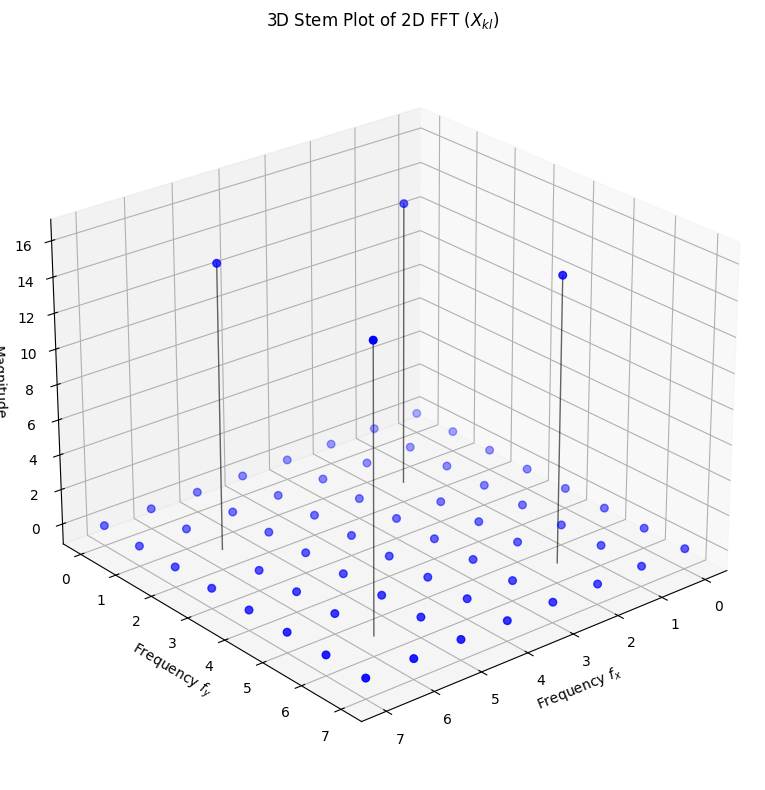

In [4]:
plot_fft_2D('fft_res_omp.json')

In [5]:
def plot_benchmark_serial(file1, file2):
	try:
		df1 = pd.read_csv(file1)
		df2 = pd.read_csv(file2)
	except Exception as e:
		print(f"Error reading file: {e}")
		return

	x = np.arange(64, 4096)

	def model(x, a):
		return a * x**2 * np.log(x)

	N = np.unique(df1['N'])

	mean_time1 = df1.groupby('N')['ExecutionTime'].mean().values
	mean_time2 = df2.groupby('N')['ExecutionTime'].mean().values

	std_time1 = df1.groupby('N')['ExecutionTime'].std().values
	std_time2 = df2.groupby('N')['ExecutionTime'].std().values

	print(mean_time1)
	print(mean_time2)

	a1, _ = scipy.optimize.curve_fit(model, N, mean_time1, sigma=std_time1)
	a2, _ = scipy.optimize.curve_fit(model, N, mean_time2, sigma=std_time2)

	# 2. Create the visualization
	plt.figure(figsize=(10, 6))
	plt.errorbar(N, mean_time1, yerr=std_time1,
				fmt='o',
				ms=5,
				capsize=3,
				color='firebrick', 
				label='iterative FFT serial',
				zorder=2)
	plt.errorbar(N, mean_time2, yerr=std_time2,
				fmt='s',
				ms=5,
				capsize=3,
				color="mediumblue", 
				label='ditfft2 FFT serial',
				zorder=2)
	plt.plot(x, a1*x*x*np.log(x), 
			linestyle='-',        # Solid line
			color="lightcoral",      # Red color
			linewidth=1, 
			label='$\\mathcal{O}(N^2\\log N)$',
			zorder=2)
	plt.plot(x, a2*x*x*np.log(x), 
			linestyle='-',        # Solid line
			color="skyblue",      # Red color
			linewidth=1, 
			label='$\\mathcal{O}(N^2\\log N)$',
			zorder=1)

	

	# 3. Add labels and styling
	plt.title('Algorithm Performance Analysis', fontsize=14)
	plt.xlabel('Matrix Size (N)', fontsize=12)
	plt.ylabel('Execution Time (seconds)', fontsize=12)
	plt.xscale('log', base=2)
	plt.grid(True, linestyle='--', alpha=0.5)
	plt.legend()

	# 4. Show the result	
	plt.show()

[1.5120000e-03 2.1443000e-03 1.1817600e-02 3.6127000e-02 1.5452940e-01
 7.2505600e-01 3.1313751e+00]
[2.0792000e-03 4.6992000e-03 2.0098300e-02 9.0076700e-02 3.9181300e-01
 1.6890002e+00 7.5140183e+00]


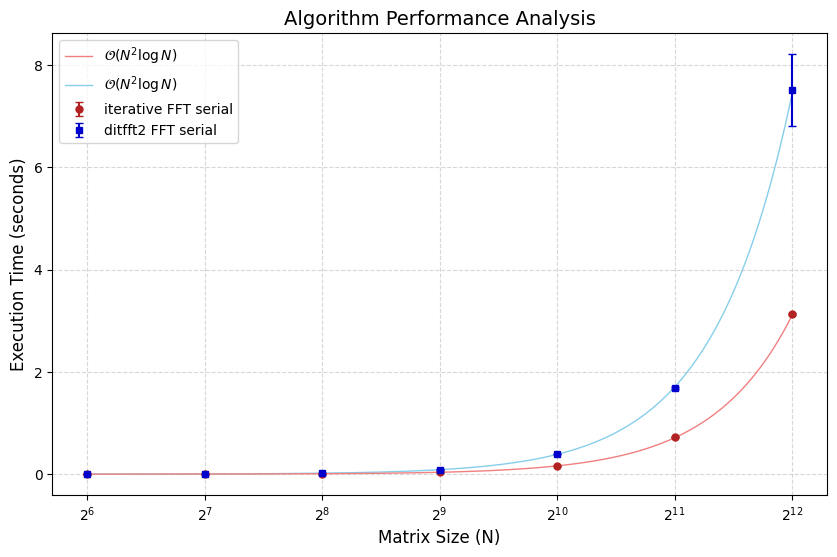

In [6]:
## using bit-reversal and precomputation of twiddle takes half of the time
plot_benchmark_serial("results_iterative_fft.csv", 'results_ditfft2.csv')

In [50]:
def plot_benchmark_openmp(file):
	try:
		df = pd.read_csv(file)
		
	except Exception as e:
		print(f"Error reading file: {e}")
		return

	x = np.arange(1, 16.1, 0.1)

	### Amdahl's law
	def model(x, a, b):
		return a / x + b
	

	n_threads = np.unique(df['NThreads'])

	mean_time = df.groupby('NThreads')['ExecutionTime'].mean().values

	std_time = df.groupby('NThreads')['ExecutionTime'].std().values

	(a, b), _ = scipy.optimize.curve_fit(model, n_threads, mean_time, sigma=std_time)

	# print(mean_time1)
	# print(mean_time2)

	# 2. Create the visualization
	plt.figure(figsize=(10, 6))
	plt.errorbar(n_threads, mean_time, yerr=std_time,
				fmt='*',
				ms=7,
				capsize=3,
				color='forestgreen', 
				label='iterative FFT openMP',
				zorder=2)
	# plt.errorbar(N, mean_time2, yerr=std_time2,
	# 			fmt='s',
	# 			ms=5,
	# 			capsize=3,
	# 			color="mediumblue", 
	# 			label='ditfft2 FFT serial',
	# 			zorder=2)
	plt.plot(x, a / x + b, 
			linestyle='-',        # Solid line
			color="limegreen",      # Red color
			linewidth=1, 
			label='Amdahl\'s law',
			zorder=2)
	# plt.plot(x, a2*x*x*np.log(x), 
	# 		linestyle='-',        # Solid line
	# 		color="skyblue",      # Red color
	# 		linewidth=1, 
	# 		label='$\\mathcal{O}(N^2\\log N)$',
	# 		zorder=1)


	

	# 3. Add labels and styling
	plt.title('Algorithm Performance Analysis', fontsize=14)
	plt.xlabel('Number of threads', fontsize=12)
	plt.ylabel('Execution Time (seconds)', fontsize=12)
	# plt.xscale('log', base=2)
	plt.grid(True, linestyle='--', alpha=0.5)
	plt.legend()

	# 4. Show the result	
	plt.show()

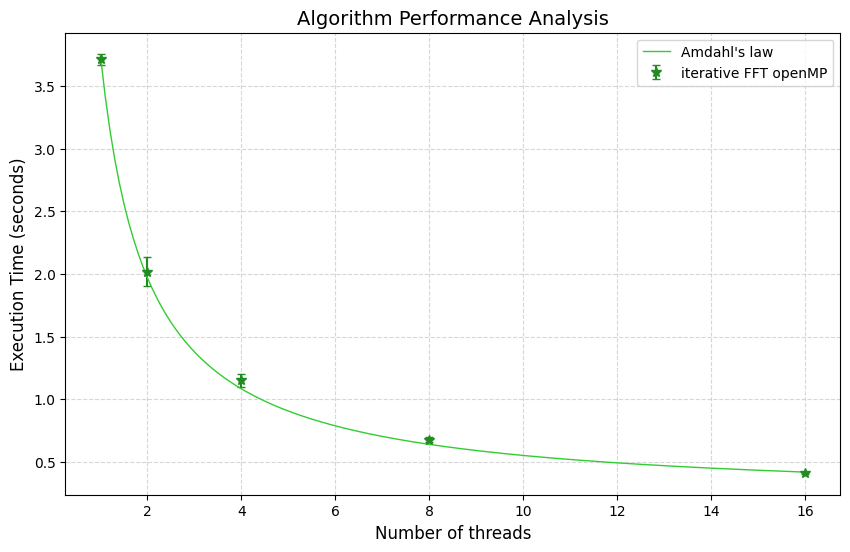

In [65]:
plot_benchmark_openmp("results_omp_4096.csv")

In [76]:
def plot_openmp_nthreads(file1, file2, file3, file4, file5, file6, file7):
	try:
		df1 = pd.read_csv(file1)
		df2 = pd.read_csv(file2)
		df3 = pd.read_csv(file3)
		df4 = pd.read_csv(file4)
		df5 = pd.read_csv(file5)
		df6 = pd.read_csv(file6)
		df7 = pd.read_csv(file7)
		
	except Exception as e:
		print(f"Error reading file: {e}")
		return

	# x = np.arange(1, 16.1, 0.1)

	# ### Amdahl's law
	# def model(x, a, b):
	# 	return a / x + b
	

	n_threads = np.unique(df1['NThreads'])

	mean_time1 = df1.groupby('NThreads')['ExecutionTime'].mean().values
	mean_time2 = df2.groupby('NThreads')['ExecutionTime'].mean().values
	mean_time3 = df3.groupby('NThreads')['ExecutionTime'].mean().values
	mean_time4 = df4.groupby('NThreads')['ExecutionTime'].mean().values
	mean_time5 = df5.groupby('NThreads')['ExecutionTime'].mean().values
	mean_time6 = df6.groupby('NThreads')['ExecutionTime'].mean().values
	mean_time7 = df7.groupby('NThreads')['ExecutionTime'].mean().values
	

	std_time1 = df1.groupby('NThreads')['ExecutionTime'].std().values
	std_time2 = df2.groupby('NThreads')['ExecutionTime'].std().values
	std_time3 = df3.groupby('NThreads')['ExecutionTime'].std().values
	std_time4 = df4.groupby('NThreads')['ExecutionTime'].std().values
	std_time5 = df5.groupby('NThreads')['ExecutionTime'].std().values
	std_time6 = df6.groupby('NThreads')['ExecutionTime'].std().values
	std_time7 = df7.groupby('NThreads')['ExecutionTime'].std().values
	

	# (a, b), _ = scipy.optimize.curve_fit(model, n_threads, mean_time, sigma=std_time)

	# print(mean_time1)
	# print(mean_time2)

	# 2. Create the visualization
	plt.figure(figsize=(10, 6))
	plt.errorbar(n_threads, mean_time1, yerr=std_time1,
				fmt='*',
				ms=7,
				capsize=3,
				color='forestgreen', 
				label='iterative FFT openMP',
				zorder=2)
	plt.errorbar(n_threads, mean_time2, yerr=std_time2,
				fmt='*',
				ms=7,
				capsize=3,
				color='red', 
				label='iterative FFT openMP',
				zorder=2)
	plt.errorbar(n_threads, mean_time3, yerr=std_time3,
				fmt='*',
				ms=7,
				capsize=3,
				color='blue', 
				label='iterative FFT openMP',
				zorder=2)
	plt.errorbar(n_threads, mean_time4, yerr=std_time4,
				fmt='*',
				ms=7,
				capsize=3,
				color='pink', 
				label='iterative FFT openMP',
				zorder=2)
	plt.errorbar(n_threads, mean_time5, yerr=std_time5,
				fmt='*',
				ms=7,
				capsize=3,
				color='orange', 
				label='iterative FFT openMP',
				zorder=2)
	plt.errorbar(n_threads, mean_time6, yerr=std_time6,
				fmt='*',
				ms=7,
				capsize=3,
				color='purple', 
				label='iterative FFT openMP',
				zorder=2)
	plt.errorbar(n_threads, mean_time7, yerr=std_time7,
				fmt='*',
				ms=7,
				capsize=3,
				color='black', 
				label='iterative FFT openMP',
				zorder=2)


	# 3. Add labels and styling
	plt.title('Algorithm Performance Analysis', fontsize=14)
	plt.xlabel('Number of threads', fontsize=12)
	plt.ylabel('Execution Time (seconds)', fontsize=12)
	plt.yscale('log')
	plt.grid(True, linestyle='--', alpha=0.5)
	plt.legend()

	# 4. Show the result	
	plt.show()

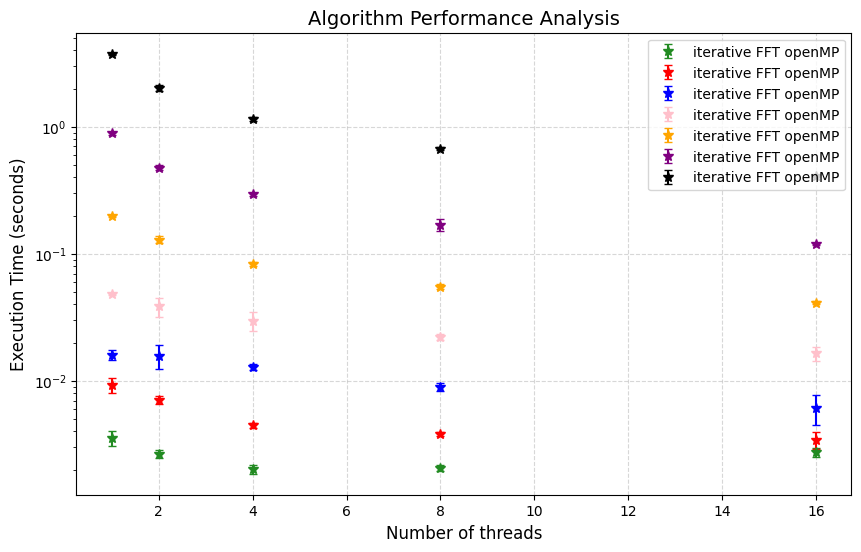

In [77]:
plot_openmp_nthreads('results_omp_64.csv', 'results_omp_128.csv', 'results_omp_256.csv', 'results_omp_512.csv', 'results_omp_1024.csv', 'results_omp_2048.csv', 'results_omp_4096.csv')